In this notebook, we use NumPy and Matplotlib to implement Gaussian processes from scratch by drawing and visualizing samples from the GP prior and posterior.

In [1]:
import numpy as np
import matplotlib.pyplot as plt 


In [2]:
# interval [a,b]
a = -1
b = 1
z = np.linspace(-1, 1, num=100) # uniform discretization of the interval [-1,1]

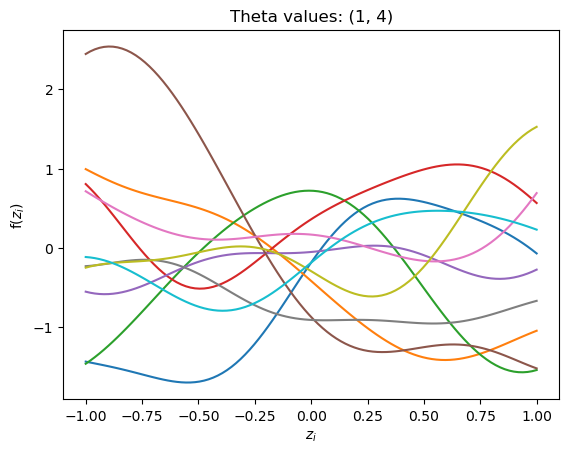

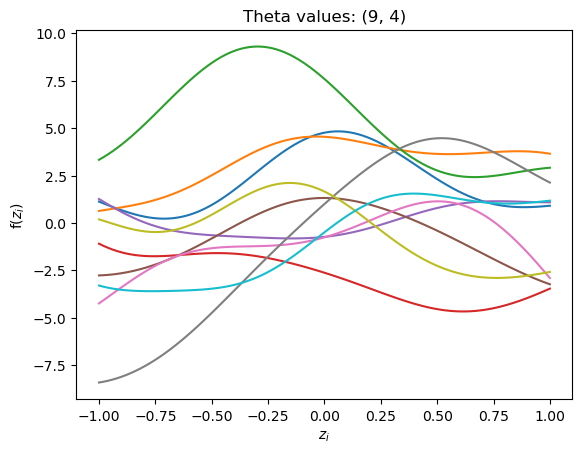

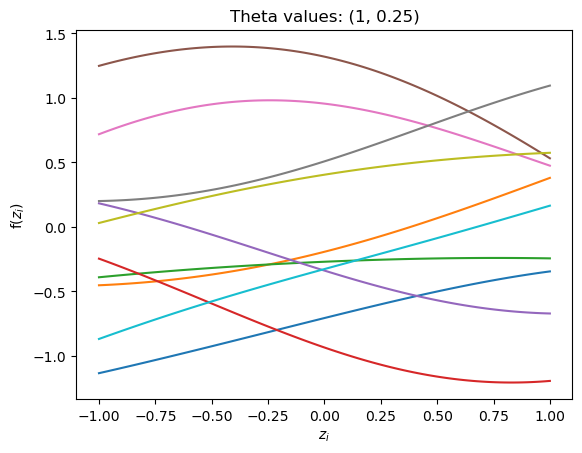

In [4]:
# Define the kernel function using vectorized operations
def kernel_matrix(z, theta_0, theta_1):
    z = np.array(z)
    diff = z[:, None] - z[None, :]  # shape (len(z), len(z))
    return theta_0 * np.exp(-theta_1 / 2 * diff**2)


thetas = [(1, 4), (9, 4), (1, 0.25)]
num_samples = 10

for theta_0, theta_1 in thetas:
    # Compute kernel matrix
    ker = kernel_matrix(z, theta_0, theta_1)

    # Sample from Gaussian Process (mean = 0)
    samples = np.random.multivariate_normal(mean=np.zeros(len(z)), cov=ker, size=num_samples)

    # Plot samples
    for i in range(num_samples):
        plt.plot(z, samples[i], label=f'Sample {i+1}')
    plt.xlabel('$z_i$')
    plt.ylabel('f($z_i$)')
    plt.title(f'Theta values: ({theta_0}, {theta_1})')
    # plt.legend()
    plt.show()


In [ ]:
# kernel function
def kernel_funct(zi,zj,theta_0,theta_1):
    return theta_0* np.exp(-theta_1/2*(zi-zj)**2)


thetas = [(1,4),(9,4),(1,0.25)]

num_samples = 10

for theta_0, theta_1 in thetas:
    # kernel matrix 

    ker = np.zeros((len(z), len(z)))  
    for i in range(len(z)):
        for j in range(len(z)):
            ker[i, j] = kernel_funct(z[i], z[j], theta_0, theta_1)
            
    # Sample from GP (mean = 0)       
    samples = np.random.multivariate_normal(mean=np.zeros(len(z)), cov=ker, size=num_samples)
    

    for i in range(num_samples):
            plt.plot(z, samples[i], label=f'Sample {i+1}')
    #plt.title(f'Theta values:({theta_0},{theta_1})')
    plt.xlabel('$z_i$')
    plt.ylabel('f($z_i$)')
    # plt.legend()
    plt.show()


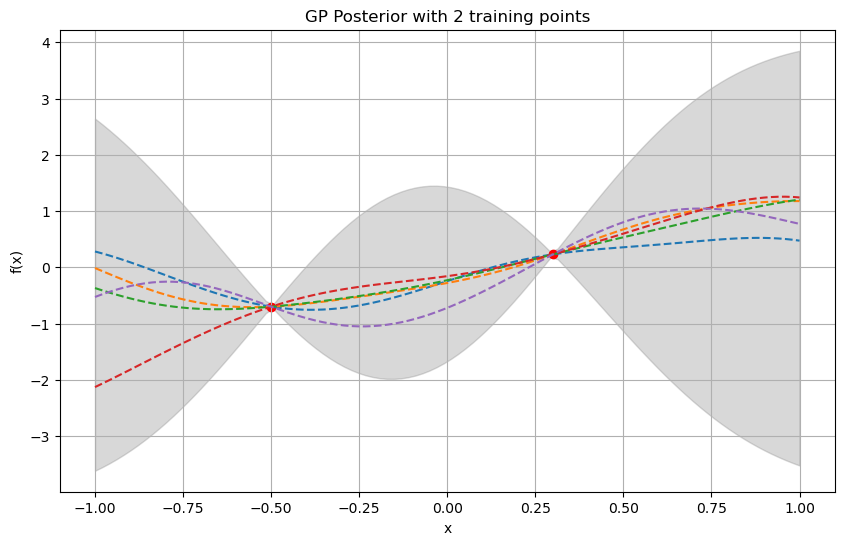

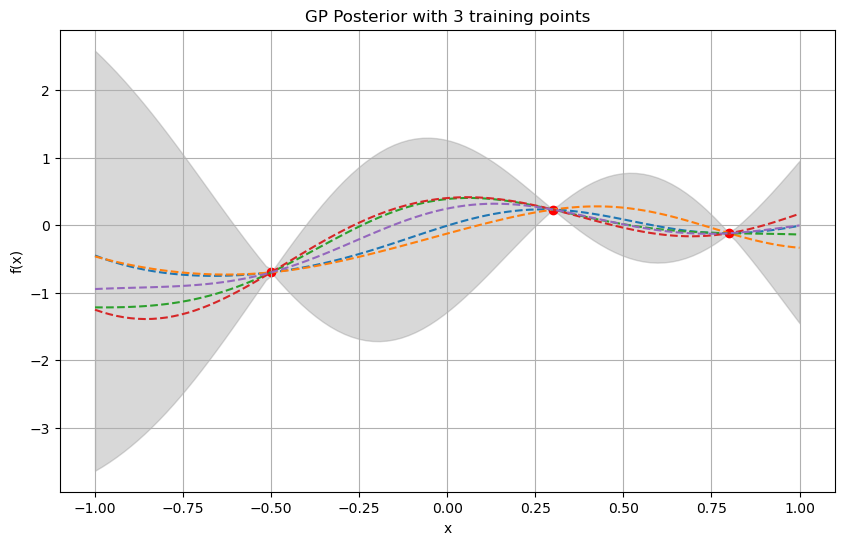

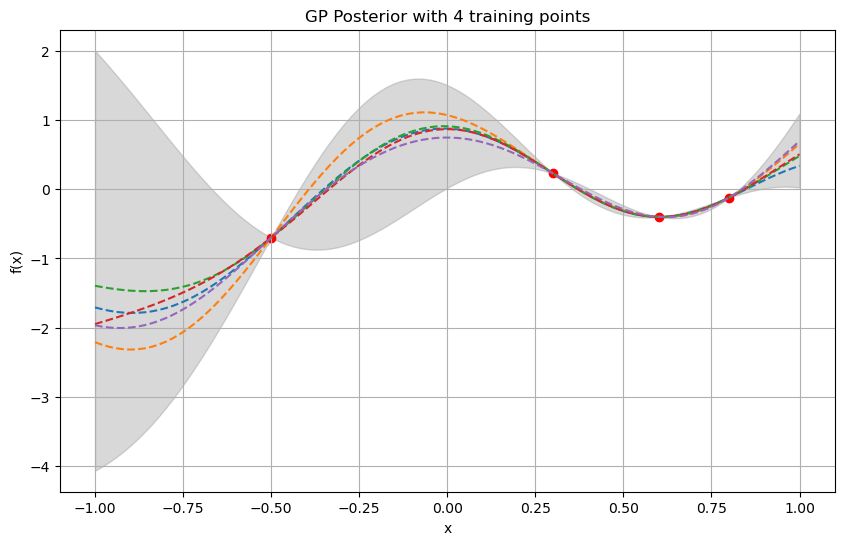

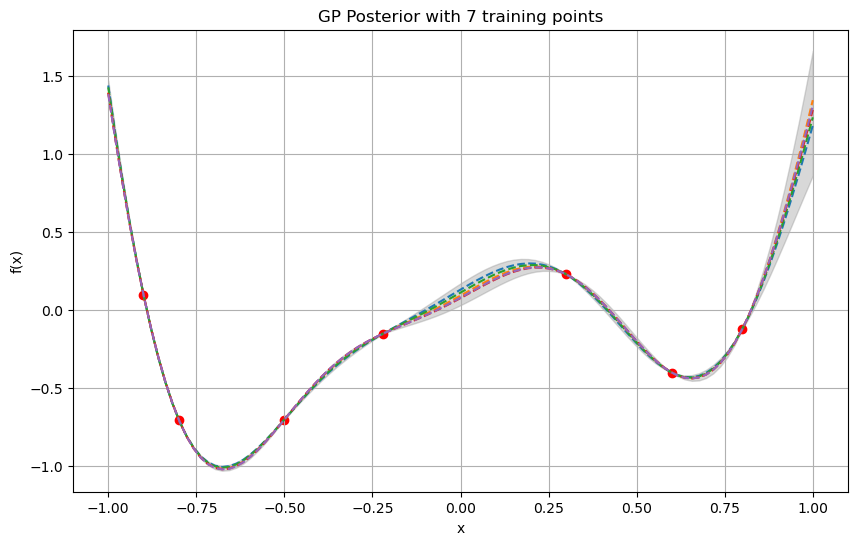

In [5]:
# Datasets with increasing training points
datasets = [
    (np.array([0.3, -0.5]), np.array([0.23, -0.7])),
    (np.array([0.3, -0.5, 0.8]), np.array([0.23, -0.7, -0.12])),
    (np.array([0.3, -0.5, 0.8, 0.6]), np.array([0.23, -0.7, -0.12, -0.4])),
    (np.array([0.3, -0.5, 0.8, 0.6, -0.9, -0.22, -0.80]), np.array([0.23, -0.7, -0.12, -0.4, 0.1, -0.15, -0.7]))
]

# Test data
X_test = np.linspace(-1, 1, 100)

# Hyperparameters
theta_0 = 1.0
theta_1 = 4.0
sigma_2 = 0.0

# Number of posterior samples (same for all datasets)
n_samples = 5

# Kernel function
def kernel_funct_matrix(x1, x2, theta_0, theta_1):
    sq_differ = (np.subtract.outer(x1, x2)) ** 2
    return theta_0 * np.exp(-theta_1 / 2 * sq_differ)

# Covariance matrices
def matrices(X_train, X_test, theta_0, theta_1, sigma_2):
    C_N = kernel_funct_matrix(X_train, X_train, theta_0, theta_1) + sigma_2 * np.eye(len(X_train))
    K_mat = kernel_funct_matrix(X_train, X_test, theta_0, theta_1)
    D = kernel_funct_matrix(X_test, X_test, theta_0, theta_1)  
    return C_N, K_mat, D


for idx, (X_train, y_train) in enumerate(datasets, 1):
    # GP posterior
    C_N, K_mat, D = matrices(X_train, X_test, theta_0, theta_1, sigma_2)

    z = np.linalg.solve(C_N, y_train)
    mean_vector = K_mat.T @ z

    W = np.linalg.solve(C_N, K_mat)
    cov_matrix = D - K_mat.T @ W  

    std_dev = np.sqrt(np.diag(cov_matrix))

    # Samples from the posterior
    samples = np.random.multivariate_normal(mean_vector, cov_matrix, size=n_samples)

    # Plot
    plt.figure(figsize=(10, 6))
    upper_bound = mean_vector + 4 * std_dev
    lower_bound = mean_vector - 4 * std_dev
    plt.fill_between(X_test, lower_bound, upper_bound, color='gray', alpha=0.3, label="±4 Std. Dev.")

    for i, sample in enumerate(samples):
        plt.plot(X_test, sample, linestyle='--', label=f"Sample {i+1}")

    plt.scatter(X_train, y_train, color='red', label='Training Data')
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)
    #plt.legend()
    plt.title(f"GP Posterior with {len(X_train)} training points")
    plt.show()


In the following snippet, $\beta^{-1}$ is nonzero.

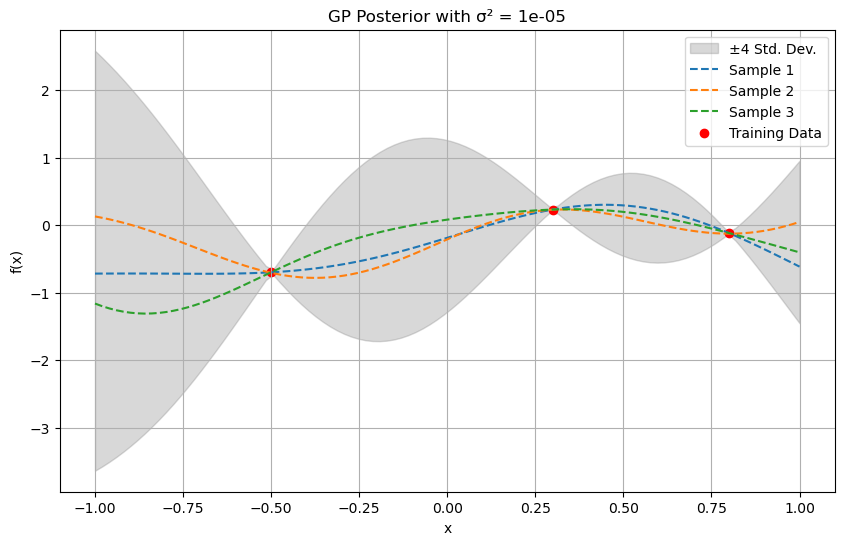

Norm of (C_N × solve(C_N, I) - I) for σ² = 1e-05: 1.623496975204672e-16


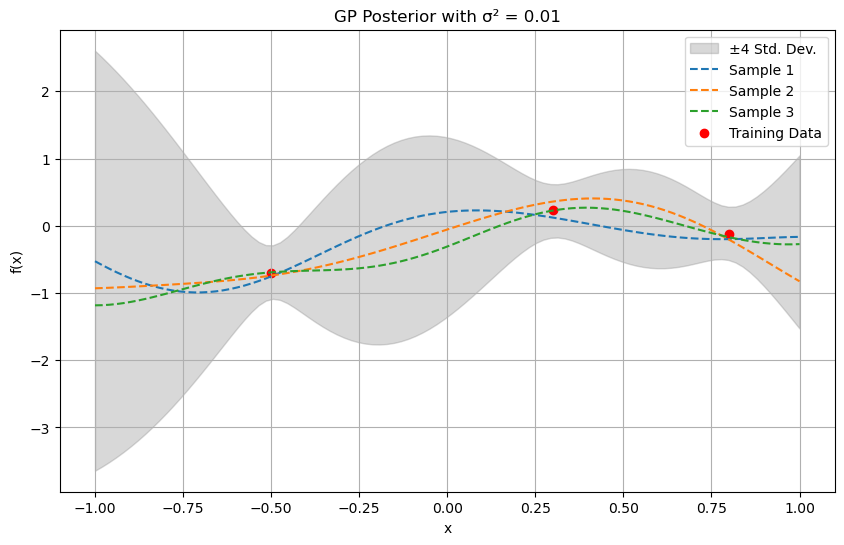

Norm of (C_N × solve(C_N, I) - I) for σ² = 0.01: 3.6228999441300433e-16


In [6]:
# Training data
X_train = np.array([0.3, -0.5, 0.8])
y_train = np.array([0.23, -0.7, -0.12])

# Test data
X_test = np.linspace(-1, 1, 100)

# Hyperparameters
theta_0 = 1.0
theta_1 = 4.0

# Kernel function
def kernel_funct_matrix(x1, x2, theta_0, theta_1):
    sq_differ = (np.subtract.outer(x1, x2)) ** 2
    return theta_0 * np.exp(-theta_1 / 2 * sq_differ)

# Covariance matrices
def matrices(X_train, X_test, theta_0, theta_1, sigma_2):
    C_N = kernel_funct_matrix(X_train, X_train, theta_0, theta_1) + sigma_2 * np.eye(len(X_train))
    K_mat = kernel_funct_matrix(X_train, X_test, theta_0, theta_1)
    D = kernel_funct_matrix(X_test, X_test, theta_0, theta_1)
    return C_N, K_mat, D

# Run for both sigma_2 values
for sigma_2 in [1e-5, 1e-2]:
    # GP posterior
    C_N, K_mat, D = matrices(X_train, X_test, theta_0, theta_1, sigma_2)

    # Solve C_N × z = y_train → z = solution
    z = np.linalg.solve(C_N, y_train)

    # mean_vector 
    mean_vector = K_mat.T @ z

    # Solve C_N × W = K_mat → W = solution
    W = np.linalg.solve(C_N, K_mat)

    # covariance matrix
    cov_matrix = D - K_mat.T @ W 

    # Standard deviation
    std_dev = np.sqrt(np.diag(cov_matrix))

    # Samples from the posterior
    n_samples = 3
    samples = np.random.multivariate_normal(mean_vector, cov_matrix, size=n_samples)

    # Plot ±4 std deviation confidence bounds
    plt.figure(figsize=(10, 6))
    upper_bound = mean_vector + 4 * std_dev
    lower_bound = mean_vector - 4 * std_dev
    plt.fill_between(X_test, lower_bound, upper_bound, color='gray', alpha=0.3, label="±4 Std. Dev.")

    # Plots 
    for i, sample in enumerate(samples):
        plt.plot(X_test, sample, label=f"Sample {i+1}", linestyle='--')

    plt.scatter(X_train, y_train, color='red', label='Training Data')
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)
    plt.legend()
    plt.title(f"GP Posterior with σ² = {sigma_2}")
    plt.show()

    # Diagnostics
    x = C_N @ np.linalg.solve(C_N, np.eye(C_N.shape[0]))
    print(f"Norm of (C_N × solve(C_N, I) - I) for σ² = {sigma_2}:", np.linalg.norm(x - np.eye(x.shape[0])))
